# Anomaly Detection Benchmark
**Workflow:** Execute cells in order.  
Paths and parameters are configured in `config/settings.yaml`.

---
## Package Installation

**Purpose:** Installs all required Python packages into the current kernel environment.

| Package | Role |
|---|---|
| `anomalib` (GitHub HEAD) | Core anomaly-detection framework |
| `anomalib[vlm,clip]` | Optional extras: Vision-Language Models and CLIP support |
| `lightning` | PyTorch Lightning training backbone (upgraded to latest) |
| `pyyaml` | YAML parser used by `load_config()` to read `settings.yaml` |
| `albumentations` | Image-augmentation library used by `src/augmentation.py` |
| `opencv-python-headless` | OpenCV build without GUI, used by `src/data_loader.py` |

> **Note:** Run this cell once per new runtime / virtual environment. Safe to re-run — `%pip install -q` is idempotent.

---

In [32]:
# ── Cell 1: Installation ──────────────────────────────────────────────────
%pip install -q git+https://github.com/openvinotoolkit/anomalib.git
%pip install -q 'anomalib[vlm,clip]'
%pip install -q -U lightning
%pip install -q pyyaml albumentations opencv-python-headless

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


---
## 1 · Environment Setup
**Source:** `config/settings.yaml` — `src/utils.py`

Mounts Google Drive, sets the working directory to the project root, loads the YAML config

| Variable | Description |
|---|---|
| `PROJECT_ROOT` | `Path` to the project directory on Google Drive |
| `cfg_path` | `Path` to `config/settings.yaml` |
| `cfg` | Full config dict loaded from `settings.yaml` |

---

In [33]:
import os
import sys
import yaml
import warnings
from pathlib import Path
from google.colab import drive

def setup_runtime_environment(remote_base_path: str) -> Path:
    """
    Args:
        remote_base_path (str): The absolute path to the project on Drive.

    Returns:
        Path: The validated project root directory.

    Raises:
        FileNotFoundError: If the project path cannot be resolved.
    """
    # Infrastructure: Ensure Google Drive is accessible
    if not os.path.exists('/content/drive'):
        drive.mount('/content/drive')

    project_root = Path(remote_base_path)

    if not project_root.exists():
        raise FileNotFoundError(f"Project directory not found: {project_root}")

    # Process Management: Update working directory and module search path
    os.chdir(project_root)
    if str(project_root) not in sys.path:
        sys.path.insert(0, str(project_root))

    return project_root

def load_settings(root: Path) -> dict:
    """
    Loads and sanitizes the project configuration.

    Args:
        root (Path): The project root directory.

    Returns:
        dict: The parsed configuration settings.
    """
    config_file = root / 'config' / 'settings.yaml'

    if not config_file.exists():
        print(f"Warning: Configuration file missing at {config_file}")
        return {}

    with open(config_file, 'r', encoding='utf-8') as stream:
        config = yaml.safe_load(stream)

    # Synchronize runtime path with configuration object
    config['project_dir'] = str(root)
    return config

# --- Runtime Execution ---

# Define the immutable project location
COLAB_PROJECT_PATH = '/content/drive/MyDrive/ADIRAS/anomaly_detection'

try:
    # Initialize core system components
    PROJECT_ROOT = setup_runtime_environment(COLAB_PROJECT_PATH)
    cfg = load_settings(PROJECT_ROOT)

    # System status
    print(f"✅ Environment:  READY")
    print(f"📂 Project Root: {PROJECT_ROOT}")
    print(f"📄 Config:       {PROJECT_ROOT / 'config/settings.yaml'}")

    # Suppress non-critical framework warnings for cleaner output
    warnings.filterwarnings("ignore", category=FutureWarning)

except Exception as error:
    print(f"❌ Initialization Failed: {error}")

✅ Environment:  READY
📂 Project Root: /content/drive/MyDrive/ADIRAS/anomaly_detection
📄 Config:       /content/drive/MyDrive/ADIRAS/anomaly_detection/config/settings.yaml


In [34]:
!pip install -q "numpy==2.0.2"

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
imagecodecs 2026.6.26 requires numpy>=2.1, but you have numpy 2.0.2 which is incompatible.


---
## 2 · Imports

**Purpose:** Loads all standard-library, third-party, and project-internal modules for the benchmark pipeline.

| Module | Source | Role |
|---|---|---|
| `build_augmentation_pipeline`, `inject_augmented_images` | `src/augmentation.py` | Build and apply Albumentations-based augmentation |
| `BenchmarkRunner` | `src/benchmarker.py` | Train models and compute metrics for one dataset category |
| `apply_channel_shuffle_dataset`, `compute_dataset_grey_norm`, `convert_dataset_to_greyscale`, `generate_black_masks` | `src/data_loader.py` | Dataset colour-mode conversions and mask generation |
| `save_run_metadata` | `src/reporter.py` | Write run metadata to `metadata.json` |
| `bootstrap_from_raw_predictions` | `src/statengine.py` | Bootstrapped confidence intervals on raw predictions |
| `_collect_images`, `_count_images`, `collect_metadata`, `load_config`, `set_seed` | `src/utils.py` | File helpers, config loading, and seed control |

---

In [35]:
import shutil
from datetime import datetime, timezone

import pandas as pd

from src.augmentation import build_augmentation_pipeline, inject_augmented_images
from src.benchmarker import BenchmarkRunner
from src.data_loader import (
    apply_channel_shuffle_dataset,
    compute_dataset_grey_norm,
    convert_dataset_to_greyscale,
    generate_black_masks,
)
from src.reporter import save_run_metadata
from src.statengine import bootstrap_from_raw_predictions
from src.utils import _collect_images, _count_images, collect_metadata, load_config, set_seed

print('Imports OK')

Imports OK


---
## 3 · Configuration & Path Setup
**Source:** `config/settings.yaml` — `src/utils.py` — `src/augmentation.py`

Loads the YAML config, resolves all paths, creates output directories, and builds the augmentation pipeline.

| Variable | Description |
|---|---|
| `cfg` | Full config dict (`settings.yaml`) |
| `global_session_id` / `run_folder` | UTC timestamp ID + dedicated output folder for this run |
| `data_source` | Dataset name, e.g. `"MVTecAD"` or `"VisA"` |
| `models_to_run` / `seeds` / `colour_modes` | Models, random seeds, and colour modes to benchmark |
| `aug_pipeline` | Compiled Albumentations augmentation pipeline |
| `mother_folder` / `all_children` | Source dataset path + sorted list of category names |

---

In [36]:
cfg = load_config(PROJECT_ROOT / 'config' / 'settings.yaml')

set_seed(cfg['training'].get('seed', 42))

paths_cfg        = cfg['paths']
run_cfg          = cfg['run']
aug_cfg          = cfg['augmentation']

output_dir       = Path(paths_cfg['output_dir'])
local_workspace  = Path(paths_cfg['local_workspace'])
local_workspace.mkdir(parents=True, exist_ok=True)
output_dir.mkdir(parents=True, exist_ok=True)

data_source   = run_cfg['data_source']
seeds         = run_cfg['seeds']
models_to_run = cfg['models']['to_run']
colour_modes  = run_cfg.get('colour_modes', ['rgb'])

timestamp        = datetime.now(timezone.utc).strftime('%Y%m%d_%H%M%S')
image_size       = cfg['training']['resize_img']
threshold_method = cfg['threshold']['method'].lower()
n_models         = len(models_to_run)
model_suffix     = models_to_run[0] if n_models == 1 else f'{n_models}models'
global_session_id = f'{timestamp}_{image_size}px_{threshold_method}_{model_suffix}'
master_folder     = output_dir
run_folder        = output_dir / f'{data_source}_{global_session_id}'
run_folder.mkdir(parents=True, exist_ok=True)

aug_pipeline  = build_augmentation_pipeline(aug_cfg)

mother_folder = Path(paths_cfg['base_dataset_root']) / data_source
if not mother_folder.exists():
    raise FileNotFoundError(
        f'Dataset folder not found: {mother_folder}\n'
        'Make sure Drive is mounted and the paths in settings.yaml are correct.'
    )
all_children = sorted(d.name for d in mother_folder.iterdir() if d.is_dir())
print(f'Dataset categories ({len(all_children)}): {all_children}')

Dataset categories (1): ['Computer']


---
## 4 · Benchmark Loop
**Source:** `src/benchmarker.py` — `src/augmentation.py` — `src/data_loader.py` — `src/statengine.py`

Main execution loop. Iterates over every dataset category and every colour mode, trains each model, evaluates it, and saves per-category CSVs.

**Loop structure:** `for child_category` → `for colour_mode` → `runner.run_benchmark()`

| Variable | Description |
|---|---|
| `local_dataset_path` | Temporary copy of the category on local SSD (`local_workspace`) |
| `colour_mode` | Active preprocessing: `rgb`, `grey_imagenet`, `grey_adapted`, or `shuffle` |
| `norm_stats` | Per-channel mean/std for `grey_adapted` normalisation; `None` otherwise |
| `runner` | `BenchmarkRunner` instance — executes training and evaluation |
| `raw_df` / `agg_df` / `lb_df` / `pw_df` / `pred_df` | Per-category result DataFrames: raw seed scores, aggregated stats, leaderboard, pairwise tests, raw predictions |
| `all_raw` / `all_agg` / … | Collector lists — accumulate DataFrames across all categories for Cell 6 |

> Local SSD data is deleted in the `finally` block after each category to preserve disk space.

---

In [37]:
 import torch
 import gc
 import time
 from IPython.display import display
 from PIL import Image
 import numpy as np
 meta = collect_metadata(
    session_id=global_session_id, seeds=seeds, models=models_to_run, config=cfg
)
save_run_metadata(meta, run_folder / 'metadata.json')

all_raw, all_agg, all_lb, all_pw, all_pred = [], [], [], [], []

for child_category in all_children:
    print(f"\n{'='*60}")
    print(f'DATASET: {child_category}')
    print(f"{'='*60}")

    local_dataset_path = local_workspace / data_source / child_category
    print('Copying dataset to local SSD...')
    shutil.copytree(mother_folder / child_category, local_dataset_path, dirs_exist_ok=True)

    if data_source == 'VisA':
        split_src = mother_folder / 'split_csv'
        split_dst = local_workspace / data_source / 'split_csv'
        if split_src.exists() and not split_dst.exists():
            shutil.copytree(split_src, split_dst)

    scrub_count = sum(
        1 for f in local_dataset_path.rglob('*_aug_*') if f.is_file() and not f.unlink()
    )
    if scrub_count:
        print(f'Removed {scrub_count} outdated augmentations.')

    for kind in ('test', 'ground_truth'):
        src = local_dataset_path / kind / 'anomaly'
        dst = local_dataset_path / kind / 'bad'
        if src.exists() and not dst.exists():
            src.rename(dst)
    # Auto-generate dummy masks if ground_truth/bad is empty
    mask_dir = local_dataset_path / 'ground_truth' / 'bad'
    test_bad_dir = local_dataset_path / 'test' / 'bad'
    if mask_dir.exists() and _count_images(mask_dir) == 0:
        print("  No masks found — generating dummy masks automatically...")

        count = 0
        for img_name in os.listdir(test_bad_dir):
            if img_name.lower().endswith(('.jpg','.jpeg','.png')):
                img = Image.open(test_bad_dir / img_name)
                mask = Image.fromarray(np.zeros((img.height, img.width), dtype=np.uint8))
                mask.save(mask_dir / (Path(img_name).stem + '.png'))
                count += 1
        print(f"  {count} dummy masks created automatically!")
    is_normal_only = (
        data_source not in ('MVTecAD', 'MVTec2', 'VisA')
        and _count_images(local_dataset_path / 'test' / 'bad') < 1
    )
    if is_normal_only:
        if not run_cfg.get('allow_normal_only_categories', False):
            print(f'SKIP {child_category}: no anomaly test images.')
            shutil.rmtree(local_dataset_path, ignore_errors=True)
            continue
        n_masks = generate_black_masks(
            test_good_dir=local_dataset_path / 'test' / 'good',
            mask_dir=local_dataset_path / 'ground_truth' / 'bad',
        )
        if n_masks:
            print(f'  {n_masks} black masks created.')

    train_good_dir  = local_dataset_path / 'train' / 'good'
    augmented_files = []
    if aug_cfg.get('enabled', False):
        n_orig = len(_collect_images(train_good_dir))
        print(f"\nAugmentation | {n_orig} originals x {aug_cfg['images_per_original']} | seed={aug_cfg['seed']}")
        augmented_files = inject_augmented_images(
            train_good_dir      = train_good_dir,
            images_per_original = aug_cfg['images_per_original'],
            pipeline            = aug_pipeline,
            aug_seed            = aug_cfg['seed'],
        )
        print(f"{len(augmented_files)} images added — Train-Set: {n_orig + len(augmented_files)}")

    if augmented_files:
        aug_dir = run_folder / 'augmented_images'
        aug_dir.mkdir(parents=True, exist_ok=True)
        shutil.make_archive(str(aug_dir / child_category), 'zip', train_good_dir)
        print(f'Zipped -> {aug_dir / child_category}.zip')

    local_source_path = local_workspace / data_source / f'{child_category}_source'
    if local_source_path.exists():
        shutil.rmtree(local_source_path)
    shutil.copytree(local_dataset_path, local_source_path)

    try:
        for colour_mode in colour_modes:
            print(f"\n{'─'*50}")
            print(f'  COLOUR MODE: {colour_mode.upper()}  ({child_category})')
            print(f"{'─'*50}")

            if local_dataset_path.exists():
                shutil.rmtree(local_dataset_path)
            shutil.copytree(local_source_path, local_dataset_path)

            norm_stats = None
            if colour_mode in ('grey_imagenet', 'grey_adapted'):
                n_conv = convert_dataset_to_greyscale(local_dataset_path)
                print(f'  {n_conv} images converted to greyscale.')
                if colour_mode == 'grey_adapted':
                    norm_stats = compute_dataset_grey_norm(local_dataset_path / 'train' / 'good')
            elif colour_mode == 'shuffle':
                perm   = tuple(run_cfg.get('channel_shuffle_permutation', [2, 0, 1]))
                n_shuf = apply_channel_shuffle_dataset(local_dataset_path, perm)
                print(f'  {n_shuf} images channel-shuffled (permutation={perm}).')

            session_id = (
                f'{global_session_id}_{colour_mode}' if len(colour_modes) > 1
                else global_session_id
            )

            _start = time.time()
            runner = BenchmarkRunner(
                data_source = data_source,
                category    = child_category,
                base_path   = local_workspace,
                output_path = master_folder,
                session_id  = session_id,
                cfg         = cfg,
                norm_stats  = norm_stats,
            )

            raw_df, agg_df, lb_df, pw_df, pred_df = runner.run_benchmark(
                model_list     = models_to_run,
                seeds          = seeds,
                checkpoint_dir = run_folder / 'checkpoints',
            )
            _elapsed = time.time() - _start
            print(f"⏱ Finished in {_elapsed/60:.1f} minutes")
            # Clear GPU memory between models

            torch.cuda.empty_cache()
            gc.collect()
            print("🧹 GPU memory cleared")

            if cfg['statistics'].get('bootstrap_on_raw', False) and not pred_df.empty:
                agg_df = bootstrap_from_raw_predictions(
                    pred_df     = pred_df,
                    raw_df      = raw_df,
                    agg_df      = agg_df,
                    n_bootstrap = cfg['statistics']['n_bootstrap'],
                    ci_level    = cfg['statistics']['ci_level'],
                )

            if len(colour_modes) > 1:
                suffix = f'_{colour_mode}'
                for df in (raw_df, agg_df, lb_df):
                    if not df.empty and 'Model' in df.columns:
                        df['Model'] = df['Model'] + suffix
                if not pw_df.empty:
                    for col in ('Model_A', 'Model_B'):
                        if col in pw_df.columns:
                            pw_df[col] = pw_df[col] + suffix
                if not pred_df.empty and 'model' in pred_df.columns:
                    pred_df['model'] = pred_df['model'] + suffix

            if not agg_df.empty:
                for df in (raw_df, agg_df, lb_df):
                    df.insert(0, 'Threshold_Method', cfg['threshold']['method'])
                    df.insert(1, 'Colour_Mode',      colour_mode)
                    df.insert(2, 'Dataset',          child_category)
                    df.insert(3, 'Aug',              aug_cfg['enabled'])
                    df.insert(4, 'Aug_x',            aug_cfg['images_per_original'] if aug_cfg['enabled'] else 0)
                if not pred_df.empty:
                    pred_df.insert(0, 'Threshold_Method', cfg['threshold']['method'])
                    pred_df.insert(1, 'Colour_Mode',      colour_mode)
                    pred_df.insert(2, 'Dataset',          child_category)

                all_raw.append(raw_df)
                all_agg.append(agg_df)
                all_lb.append(lb_df)
                all_pw.append(pw_df)
                if not pred_df.empty:
                    all_pred.append(pred_df)

                pfx = run_folder / f'{data_source}_{child_category}_{colour_mode}'
                raw_df.to_csv(f'{pfx}_raw_seeds.csv',        index=False)
                agg_df.to_csv(f'{pfx}_aggregated_stats.csv', index=False)
                lb_df.to_csv( f'{pfx}_leaderboard.csv',      index=False)
                if not pw_df.empty:
                    pw_df.to_csv(f'{pfx}_pairwise_tests.csv', index=False)
                if not pred_df.empty:
                    pred_df.to_csv(f'{pfx}_raw_predictions.csv', index=False)


                print(f'\nLEADERBOARD — {child_category} [{colour_mode.upper()}]')
                display(lb_df)

    finally:
        print('Cleaning local SSD...')
        shutil.rmtree(local_dataset_path, ignore_errors=True)
        if local_source_path.exists():
            shutil.rmtree(local_source_path, ignore_errors=True)


DATASET: Computer
Copying dataset to local SSD...

Augmentation | 46 originals x 1 | seed=3
46 images added — Train-Set: 92


INFO:lightning_fabric.utilities.seed:Seed set to 420


Zipped -> /content/drive/MyDrive/ADIRAS/results_elma_benchmark/ROIDataset_20260629_120253_256px_noise_injection_6models/augmented_images/Computer.zip

──────────────────────────────────────────────────
  COLOUR MODE: RGB  (Computer)
──────────────────────────────────────────────────
Dataset Root: /content/local_workspace/ROIDataset/Computer
Session: 20260629_120253_256px_noise_injection_6models | Dataset: Computer | Seeds: [420]

Model: AnomalyDINO
  Seed: 420
  Threshold method: NOISE_INJECTION
  Adaptive noise std: avg_std=31.0 * 1.0 = 31.0
  Pseudo-anomaly methods active: ['gauss', 'noise_patch', 'color_patch', 'multiplicative', 'shot']


/content/drive/MyDrive/ADIRAS/anomaly_detection/src/data_loader.py:241: UserWarning: Argument(s) 'multiplier_range' are not valid for transform MultiplicativeNoise
  "multiplicative": A.MultiplicativeNoise(


  Pseudo-anomaly val created: 15 normal | 15 pseudo-anomalous
  PostProcessor: F1AdaptiveThreshold


...

INFO:pytorch_lightning.utilities.rank_zero:The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/saving.py:365: Skipping 'evaluator' parameter because it is not possible to safely dump to YAML.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        image_AUPR         │    0.9234328269958496     │
│        image_AUROC        │    0.7468531131744385     │
│       image_F1Score       │    0.8849557638168335     │
│        pixel_AUPR         │    0.35333722829818726    │
│        pixel_AUPRO        │    0.6705138683319092     │
│        pixel_AUROC        │    0.9876241683959961     │
│       pixel_F1Score       │    0.20698519051074982    │
│     pixel_SafeAUPIMO      │    0.19206042519469188    │
└───────────────────────────┴───────────────────────────┘

  Saving outputs to Drive...
  raw_seeds.csv saved for Uflow (1 seed(s))
⏱ Finished in 40.5 minutes
🧹 GPU memory cleared

LEADERBOARD — Computer [RGB]


,Threshold_Method,Colour_Mode,Dataset,Aug,Aug_x,Rank,Model,Image AUROC,vs Best
0,NOISE_INJECTION,rgb,Computer,True,1,1,Uflow,0.7469 [CI pending],—
1,NOISE_INJECTION,rgb,Computer,True,1,2,Fastflow,0.6531 [CI pending],N/A
2,NOISE_INJECTION,rgb,Computer,True,1,3,Padim,0.4923 [CI pending],N/A
3,NOISE_INJECTION,rgb,Computer,True,1,4,WinClip,0.4685 [CI pending],N/A
4,NOISE_INJECTION,rgb,Computer,True,1,5,AnomalyDINO,0.4671 [CI pending],N/A
5,NOISE_INJECTION,rgb,Computer,True,1,6,Patchcore,0.4601 [CI pending],N/A


Cleaning local SSD...


---
## 5 · Results Consolidation
**Source:** output of Cell 4

Concatenates all per-category DataFrames into global CSV files and writes them to `run_folder`.

| Output file | Content |
|---|---|
| `ALL_raw_seeds.csv` | Raw metric scores per model, seed, and category |
| `ALL_aggregated_stats.csv` | Mean, std, and confidence intervals across seeds |
| `ALL_leaderboard.csv` | Ranked model comparison per category |
| `ALL_pairwise_tests.csv` | Statistical pairwise significance tests (if available) |
| `ALL_raw_predictions.csv` | Per-image anomaly scores and ground-truth labels (if available) |

---

In [38]:
# ── Cell 6: Consolidate overall results ──────────────────────────────────
if all_raw:
    pd.concat(all_raw,  ignore_index=True).to_csv(run_folder / 'ALL_raw_seeds.csv',        index=False)
    pd.concat(all_agg,  ignore_index=True).to_csv(run_folder / 'ALL_aggregated_stats.csv', index=False)
    pd.concat(all_lb,   ignore_index=True).to_csv(run_folder / 'ALL_leaderboard.csv',      index=False)
    if all_pw:
        pd.concat(all_pw,   ignore_index=True).to_csv(run_folder / 'ALL_pairwise_tests.csv',  index=False)
    if all_pred:
        pd.concat(all_pred, ignore_index=True).to_csv(run_folder / 'ALL_raw_predictions.csv', index=False)

print(f'\nBenchmark complete. Results in: {run_folder}')


Benchmark complete. Results in: /content/drive/MyDrive/ADIRAS/results_elma_benchmark/ROIDataset_20260629_120253_256px_noise_injection_6models


## 6 ·Dashboard

Loading results...
  ✅ AnomalyDINO: loaded from ROIDataset_20260629_120253_256px_noise_injection_6models
  ✅ Padim: loaded from ROIDataset_20260629_120253_256px_noise_injection_6models
  ✅ Patchcore: loaded from ROIDataset_20260629_120253_256px_noise_injection_6models
  ✅ WinClip: loaded from ROIDataset_20260629_120253_256px_noise_injection_6models
  ✅ Fastflow: loaded from ROIDataset_20260629_120253_256px_noise_injection_6models
  ✅ Uflow: loaded from ROIDataset_20260629_120253_256px_noise_injection_6models
  ✅ Dinomaly: loaded from MaskedDataset_20260619_134219_448px_noise_injection_Dinomaly


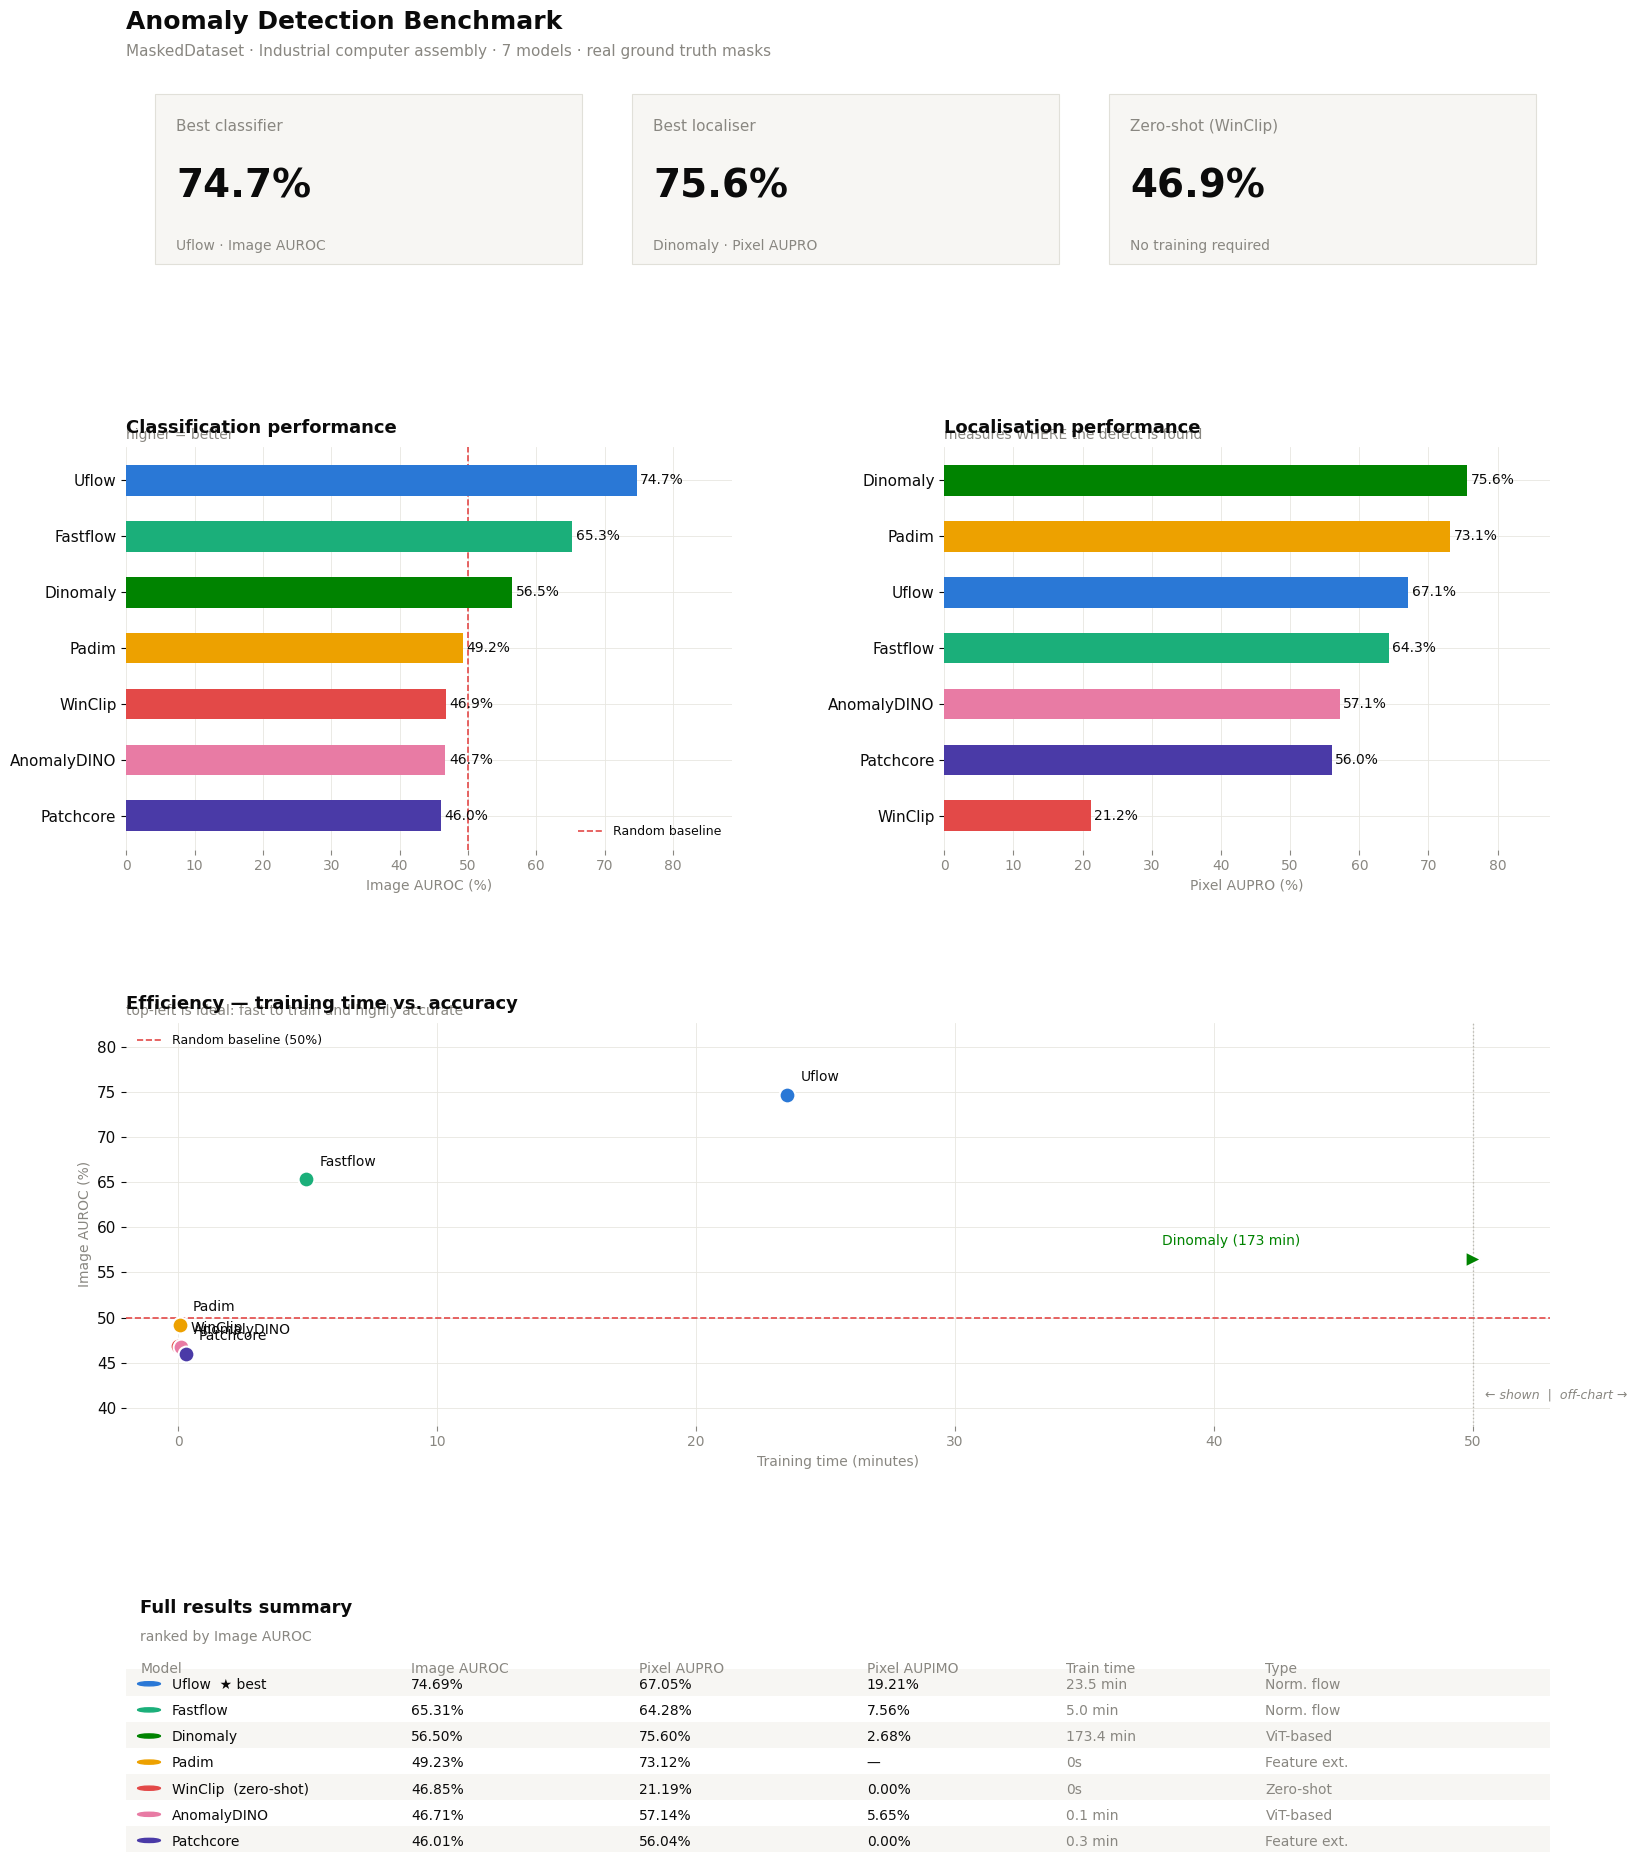


✅ Dashboard saved to Drive!


In [39]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from pathlib import Path

# ── Auto-load latest results ───────────────────────────────────────────────
results_dir = Path('/content/drive/MyDrive/ADIRAS/results_elma_benchmark')

def load_best_results(results_dir):
    model_data = {}
    all_folders = sorted(
        [f for f in results_dir.iterdir() if f.is_dir()],
        reverse=True
    )
    for folder in all_folders:
        computer_dir = folder / 'Computer'
        if not computer_dir.exists():
            continue
        for model_dir in computer_dir.iterdir():
            if not model_dir.is_dir():
                continue
            model_name = model_dir.name
            csv_path   = model_dir / 'raw_seeds.csv'
            if csv_path.exists() and model_name not in model_data:
                df = pd.read_csv(csv_path)
                df['Model'] = model_name
                model_data[model_name] = df
                print(f"  ✅ {model_name}: loaded from {folder.name}")
    if not model_data:
        raise ValueError("No results found!")
    return pd.concat(model_data.values(), ignore_index=True)

print("Loading results...")
df = load_best_results(results_dir)

agg = df.groupby('Model').agg({
    'Image AUROC':  'mean',
    'Pixel AUPRO':  'mean',
    'Pixel AUPIMO': 'mean',
    'Train Time':   'mean',
}).reset_index()

for col in ['Image AUROC', 'Pixel AUPRO', 'Pixel AUPIMO']:
    agg[col] = agg[col] * 100

agg['Train Time (min)'] = agg['Train Time'] / 60
agg = agg.sort_values('Image AUROC', ascending=False).reset_index(drop=True)

PALETTE = {
    'Uflow':       '#2a78d6',
    'Fastflow':    '#1baf7a',
    'Padim':       '#eda100',
    'Patchcore':   '#4a3aa7',
    'WinClip':     '#e34948',
    'AnomalyDINO': '#e87ba4',
    'Dinomaly':    '#008300',
}
DEFAULT_COLORS = ['#2a78d6','#1baf7a','#eda100','#4a3aa7','#e34948','#e87ba4','#008300']
agg['color'] = [PALETTE.get(m, DEFAULT_COLORS[i % len(DEFAULT_COLORS)]) for i, m in enumerate(agg['Model'])]

TYPE_MAP = {
    'Uflow':       'Norm. flow',
    'Fastflow':    'Norm. flow',
    'Padim':       'Feature ext.',
    'Patchcore':   'Feature ext.',
    'WinClip':     'Zero-shot',
    'AnomalyDINO': 'ViT-based',
    'Dinomaly':    'ViT-based',
}
agg['Type'] = agg['Model'].map(lambda m: TYPE_MAP.get(m, 'Other'))

# ── Style ─────────────────────────────────────────────────────────────────
BG      = '#ffffff'
SURFACE = '#f7f6f3'
BORDER  = '#e1e0d9'
TEXT    = '#0b0b0b'
MUTED   = '#898781'
GRID    = '#e8e7e0'

plt.rcParams.update({
    'font.family':        'DejaVu Sans',
    'font.size':          11,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.spines.left':   False,
    'axes.spines.bottom': False,
    'axes.grid':          True,
    'grid.color':         GRID,
    'grid.linewidth':     0.6,
    'axes.facecolor':     BG,
    'figure.facecolor':   BG,
    'text.color':         TEXT,
    'axes.labelcolor':    MUTED,
    'xtick.color':        MUTED,
    'ytick.color':        TEXT,
    'xtick.labelsize':    10,
    'ytick.labelsize':    11,
})

n_models = len(agg)
n_rows   = n_models + 2

fig = plt.figure(figsize=(16, 20), facecolor=BG)
gs  = gridspec.GridSpec(
    4, 2, figure=fig,
    height_ratios=[1.2, 2.5, 2.5, n_rows * 0.18],
    hspace=0.55, wspace=0.35,
    top=0.93, bottom=0.04,
    left=0.08, right=0.97
)

# ── Title ─────────────────────────────────────────────────────────────────
fig.text(0.08, 0.965, 'Anomaly Detection Benchmark',
         fontsize=18, fontweight='bold', color=TEXT, va='top')
fig.text(0.08, 0.948,
         f'MaskedDataset · Industrial computer assembly · {n_models} models · real ground truth masks',
         fontsize=11, color=MUTED, va='top')

# ── KPI cards ─────────────────────────────────────────────────────────────
best_auroc_row = agg.iloc[0]
best_aupro_row = agg.loc[agg['Pixel AUPRO'].idxmax()]
winclip_row    = agg[agg['Model'] == 'WinClip']

kpi_values = [
    ('Best classifier',
     f"{best_auroc_row['Image AUROC']:.1f}%",
     f"{best_auroc_row['Model']} · Image AUROC"),
    ('Best localiser',
     f"{best_aupro_row['Pixel AUPRO']:.1f}%",
     f"{best_aupro_row['Model']} · Pixel AUPRO"),
    ('Zero-shot (WinClip)',
     f"{winclip_row['Image AUROC'].values[0]:.1f}%" if len(winclip_row) else 'N/A',
     'No training required'),
]

ax_kpi = fig.add_subplot(gs[0, :])
ax_kpi.axis('off')
ax_kpi.set_xlim(0, 1)
ax_kpi.set_ylim(0, 1)

for i, (label, value, sub) in enumerate(kpi_values):
    x0 = 0.02 + i * 0.335
    rect = plt.Rectangle((x0, 0.05), 0.30, 0.88,
                          transform=ax_kpi.transAxes,
                          facecolor=SURFACE, edgecolor=BORDER,
                          linewidth=0.8, clip_on=False)
    ax_kpi.add_patch(rect)
    ax_kpi.text(x0 + 0.015, 0.80, label,
                transform=ax_kpi.transAxes,
                fontsize=11, color=MUTED, va='top')
    ax_kpi.text(x0 + 0.015, 0.55, value,
                transform=ax_kpi.transAxes,
                fontsize=28, fontweight='bold', color=TEXT, va='top')
    ax_kpi.text(x0 + 0.015, 0.18, sub,
                transform=ax_kpi.transAxes,
                fontsize=10, color=MUTED, va='top')

# ── Plot 1: Image AUROC ────────────────────────────────────────────────────
agg_auroc = agg.sort_values('Image AUROC')
ax1 = fig.add_subplot(gs[1, 0])
bars = ax1.barh(agg_auroc['Model'], agg_auroc['Image AUROC'],
                color=list(agg_auroc['color']), height=0.55, zorder=3)
ax1.axvline(50, color='#e34948', linestyle='--', linewidth=1.2,
            label='Random baseline', zorder=2)
for bar, val in zip(bars, agg_auroc['Image AUROC']):
    ax1.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=10,
             color=TEXT, fontweight='500')
ax1.set_xlim(0, agg['Image AUROC'].max() + 14)
ax1.set_xlabel('Image AUROC (%)', color=MUTED, fontsize=10)
ax1.set_title('Classification performance', fontsize=13,
              fontweight='bold', color=TEXT, pad=10, loc='left')
ax1.text(0, 1.02, 'higher = better',
         transform=ax1.transAxes, fontsize=10, color=MUTED)
ax1.legend(fontsize=9, frameon=False, loc='lower right')
ax1.grid(axis='x', zorder=0)
ax1.set_axisbelow(True)

# ── Plot 2: Pixel AUPRO ───────────────────────────────────────────────────
agg_aupro = agg.sort_values('Pixel AUPRO')
ax2 = fig.add_subplot(gs[1, 1])
bars2 = ax2.barh(agg_aupro['Model'], agg_aupro['Pixel AUPRO'],
                 color=list(agg_aupro['color']), height=0.55, zorder=3)
for bar, val in zip(bars2, agg_aupro['Pixel AUPRO']):
    ax2.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=10, color=TEXT)
ax2.set_xlim(0, agg['Pixel AUPRO'].max() + 12)
ax2.set_xlabel('Pixel AUPRO (%)', color=MUTED, fontsize=10)
ax2.set_title('Localisation performance', fontsize=13,
              fontweight='bold', color=TEXT, pad=10, loc='left')
ax2.text(0, 1.02, 'measures WHERE the defect is found',
         transform=ax2.transAxes, fontsize=10, color=MUTED)
ax2.grid(axis='x', zorder=0)
ax2.set_axisbelow(True)

# ── Plot 3: Efficiency scatter (cap at 50 min) ────────────────────────────
ax3 = fig.add_subplot(gs[2, :])
TIME_CAP = 50
ax3.axhline(50, color='#e34948', linestyle='--', linewidth=1.2,
            label='Random baseline (50%)', zorder=2)
ax3.axvline(TIME_CAP, color=MUTED, linestyle=':', linewidth=1.0,
            alpha=0.5, zorder=2)
ax3.text(TIME_CAP + 0.5,
         agg['Image AUROC'].min() - 5,
         '← shown  |  off-chart →',
         fontsize=9, color=MUTED, style='italic')

for _, row in agg.iterrows():
    t = row['Train Time (min)']
    a = row['Image AUROC']
    c = row['color']
    if t <= TIME_CAP:
        ax3.scatter(t, a, color=c, s=130, zorder=5,
                    linewidths=1.5, edgecolors='white')
        ax3.annotate(row['Model'], (t, a),
                     xytext=(t + 0.5, a + 1.5),
                     fontsize=10, color=TEXT)
    else:
        # Show off-chart models as note on right edge
        ax3.scatter(TIME_CAP, a, color=c, s=130, zorder=5,
                    marker='>', linewidths=1.5, edgecolors='white')
        ax3.annotate(f"{row['Model']} ({t:.0f} min)",
                     (TIME_CAP, a),
                     xytext=(TIME_CAP - 12, a + 1.5),
                     fontsize=10, color=c)

ax3.set_xlim(-2, TIME_CAP + 3)
ax3.set_ylim(agg['Image AUROC'].min() - 8,
             agg['Image AUROC'].max() + 8)
ax3.set_xlabel('Training time (minutes)', color=MUTED, fontsize=10)
ax3.set_ylabel('Image AUROC (%)',         color=MUTED, fontsize=10)
ax3.set_title('Efficiency — training time vs. accuracy',
              fontsize=13, fontweight='bold', color=TEXT, pad=10, loc='left')
ax3.text(0, 1.02, 'top-left is ideal: fast to train and highly accurate',
         transform=ax3.transAxes, fontsize=10, color=MUTED)
ax3.legend(fontsize=9, frameon=False)
ax3.grid(zorder=0)
ax3.set_axisbelow(True)

# ── Plot 4: Summary table ──────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[3, :])
ax4.axis('off')
ax4.set_xlim(0, 1)
ax4.set_ylim(0, 1)

headers = ['Model', 'Image AUROC', 'Pixel AUPRO',
           'Pixel AUPIMO', 'Train time', 'Type']
col_x   = [0.01, 0.20, 0.36, 0.52, 0.66, 0.80]
row_h   = 1.0 / (n_rows + 1)

ax4.text(col_x[0], 1.0, 'Full results summary',
         fontsize=13, fontweight='bold', color=TEXT,
         transform=ax4.transAxes, va='top')
ax4.text(col_x[0], 0.88, 'ranked by Image AUROC',
         fontsize=10, color=MUTED,
         transform=ax4.transAxes, va='top')

header_y = 0.76
for j, h in enumerate(headers):
    ax4.text(col_x[j], header_y, h, fontsize=10,
             color=MUTED, fontweight='500',
             transform=ax4.transAxes, va='top')

for i, row in agg.iterrows():
    y = header_y - (i + 1) * row_h - 0.02
    bg = SURFACE if i % 2 == 0 else BG
    rect = plt.Rectangle((0, y - 0.01), 1.0, row_h,
                          transform=ax4.transAxes,
                          facecolor=bg, clip_on=False)
    ax4.add_patch(rect)

    dot = plt.Circle((col_x[0] + 0.006, y + row_h * 0.35),
                     0.008, color=row['color'],
                     transform=ax4.transAxes, clip_on=False)
    ax4.add_patch(dot)

    label = row['Model']
    if i == 0:
        label += '  ★ best'
    if row['Model'] == 'WinClip':
        label += '  (zero-shot)'

    aupimo_str = f"{row['Pixel AUPIMO']:.2f}%" \
                 if pd.notna(row['Pixel AUPIMO']) else '—'
    time_str   = '0s' if row['Train Time (min)'] < 0.1 \
                 else f"{row['Train Time (min)']:.1f} min"

    ax4.text(col_x[0] + 0.022, y + row_h * 0.3,
             label, fontsize=10, color=TEXT,
             fontweight='500' if i == 0 else '400',
             transform=ax4.transAxes, va='center')
    ax4.text(col_x[1], y + row_h * 0.3,
             f"{row['Image AUROC']:.2f}%", fontsize=10, color=TEXT,
             fontweight='500' if i == 0 else '400',
             transform=ax4.transAxes, va='center')
    ax4.text(col_x[2], y + row_h * 0.3,
             f"{row['Pixel AUPRO']:.2f}%", fontsize=10,
             color=TEXT, transform=ax4.transAxes, va='center')
    ax4.text(col_x[3], y + row_h * 0.3,
             aupimo_str, fontsize=10,
             color=TEXT, transform=ax4.transAxes, va='center')
    ax4.text(col_x[4], y + row_h * 0.3,
             time_str, fontsize=10,
             color=MUTED, transform=ax4.transAxes, va='center')
    ax4.text(col_x[5], y + row_h * 0.3,
             row['Type'], fontsize=10,
             color=MUTED, transform=ax4.transAxes, va='center')

# ── Save ──────────────────────────────────────────────────────────────────
output_path = '/content/drive/MyDrive/ADIRAS/results_elma_benchmark/benchmark_dashboard.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(f'\n✅ Dashboard saved to Drive!')

# 7 · ROI Dataset Creation

In [ ]:
import cv2
import shutil
import numpy as np
from pathlib import Path

# ── ROI coordinates from ground truth analysis ─────────────────────────────
RMIN, RMAX = 815, 2518
CMIN, CMAX = 503, 2490

src_dataset = Path('/content/drive/MyDrive/ADIRAS/datasets/MaskedDataset/Computer')
dst_dataset = Path('/content/drive/MyDrive/ADIRAS/datasets/ROIDataset/Computer')

splits = [
    ('train/good',          'train/good',          False),
    ('test/good',           'test/good',            False),
    ('test/anomaly',        'test/anomaly',         False),
    ('ground_truth/anomaly','ground_truth/anomaly', True),
]

total = 0
for src_split, dst_split, is_mask in splits:
    src_dir = src_dataset / src_split
    dst_dir = dst_dataset / dst_split
    dst_dir.mkdir(parents=True, exist_ok=True)

    images = list(src_dir.glob('*.png')) + list(src_dir.glob('*.jpg'))
    print(f"\n{src_split}: {len(images)} images")

    for img_path in images:
        img = cv2.imread(str(img_path),
                         cv2.IMREAD_GRAYSCALE if is_mask else cv2.IMREAD_COLOR)
        if img is None:
            continue

        # Crop to ROI
        crop = img[RMIN:RMAX, CMIN:CMAX]

        # Resize to 256x256 for pipeline compatibility
        crop_resized = cv2.resize(crop, (256, 256),
                                  interpolation=cv2.INTER_NEAREST if is_mask
                                  else cv2.INTER_LINEAR)

        dst_path = dst_dir / img_path.name
        cv2.imwrite(str(dst_path), crop_resized)
        total += 1

print(f"\n✅ ROI dataset created! Total: {total} images")
print(f"   Saved to: {dst_dataset}")

# Verify
for split, _, _ in splits:
    n = len(list((dst_dataset / split).glob('*')))
    print(f"   {split}: {n} images")

In [ ]:
import os
os.chdir('/content/drive/MyDrive/ADIRAS/anomaly_detection')
!git config --global user.email "your_github_email@example.com"
!git config --global user.name "ayagh1"
!git add .
!git commit -m "Clean notebook + ROI experiment + dynamic dashboard"
!git push origin master